# IT549 Lab 4 — Object Detection Evolution: From R-CNN to YOLO

This notebook is organized exactly by task:
- Preparation: Ground Truth Visualization
- Task 1: IoU
- Task 2: Selective Search
- Task 3: R-CNN feature extraction
- Task 4: Fast R-CNN RoI pooling
- Task 5: Faster R-CNN
- Task 6: NMS
- Task 7: YOLO fine-tuning

In [1]:
!pip -q install opencv-contrib-python ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [2]:
import os
import glob
import random
import time
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.ops import roi_pool
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

from PIL import Image
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ZIP_PATH = "/content/archive.zip"
UNZIP_DIR = "/content/unzipped_archive"

if os.path.exists(ZIP_PATH) and not os.path.exists(UNZIP_DIR):
    os.makedirs(UNZIP_DIR, exist_ok=True)
    !unzip -q /content/archive.zip -d /content/unzipped_archive

def find_first_existing_dir(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("None of the expected dataset paths exist.")

TRAIN_DIR = find_first_existing_dir([
    "/content/unzipped_archive/train_zip/train",
    "/content/unzipped_archive/archive/train_zip/train",
    "/content/train_zip/train",
    "/content/archive/train_zip/train",
])

TEST_DIR = find_first_existing_dir([
    "/content/unzipped_archive/test_zip/test",
    "/content/unzipped_archive/archive/test_zip/test",
    "/content/test_zip/test",
    "/content/archive/test_zip/test",
])

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

CLASS_NAMES = ["apple", "banana", "orange"]
CLASS_MAP = {"apple": 0, "banana": 1, "orange": 2}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def list_images(folder):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

def find_xml(image_path):
    stem = Path(image_path).stem
    return os.path.join(os.path.dirname(image_path), stem + ".xml")

def read_bgr(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return img

def show_bgr(img_bgr, title="", figsize=(10, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def clamp_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    x1 = max(0, min(w - 1, int(round(x1))))
    y1 = max(0, min(h - 1, int(round(y1))))
    x2 = max(0, min(w - 1, int(round(x2))))
    y2 = max(0, min(h - 1, int(round(y2))))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return [x1, y1, x2, y2]

def parse_voc_xml(xml_path):
    boxes, labels = [], []
    tree = ET.parse(xml_path)
    root = tree.getroot()
    for obj in root.findall("object"):
        name = obj.find("name").text.strip().lower()
        bnd = obj.find("bndbox")
        x1 = float(bnd.find("xmin").text)
        y1 = float(bnd.find("ymin").text)
        x2 = float(bnd.find("xmax").text)
        y2 = float(bnd.find("ymax").text)
        boxes.append([x1, y1, x2, y2])
        labels.append(name)
    return boxes, labels

def draw_boxes_cv2(img_bgr, boxes, labels=None, scores=None, color=(0, 255, 0), thickness=2):
    out = img_bgr.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = clamp_box_xyxy(box, out.shape[1], out.shape[0])
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
        text = ""
        if labels is not None and i < len(labels):
            text += str(labels[i])
        if scores is not None and i < len(scores):
            text += " {:.2f}".format(scores[i])
        if text:
            y_text = max(15, y1 - 5)
            cv2.putText(out, text, (x1, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return out

def get_random_sample(folder):
    imgs = list_images(folder)
    random.shuffle(imgs)
    for img_path in imgs:
        xml_path = find_xml(img_path)
        if os.path.exists(xml_path):
            return img_path, xml_path
    raise RuntimeError("No image+xml pair found.")

def normalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN, device=t.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=t.device).view(3, 1, 1)
    return (t - mean) / std

def get_image_tensor(path):
    return TF.to_tensor(Image.open(path).convert("RGB"))

def iou_xyxy(box1, box2, eps=1e-7):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - inter_area
    return inter_area / (union + eps)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cpu
TRAIN_DIR: /content/unzipped_archive/train_zip/train
TEST_DIR: /content/unzipped_archive/test_zip/test


## Preparation: Ground Truth Visualization

Image: /content/unzipped_archive/train_zip/train/apple_51.jpg
XML: /content/unzipped_archive/train_zip/train/apple_51.xml


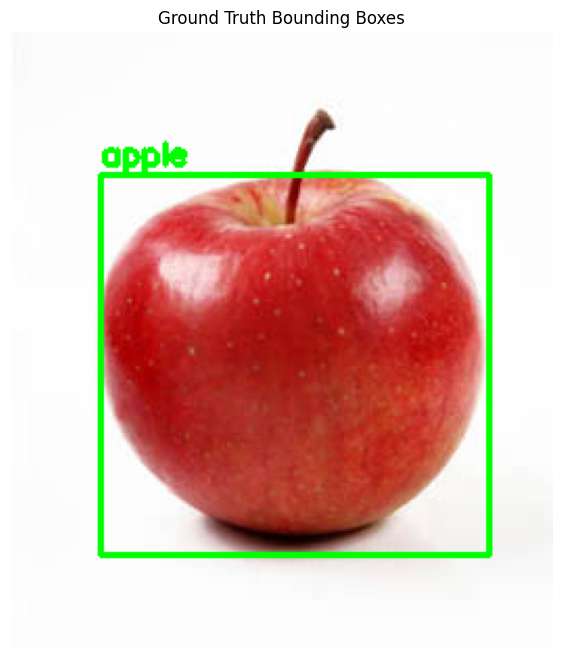

In [3]:
img_path, xml_path = get_random_sample(TRAIN_DIR)
img_bgr = read_bgr(img_path)
h, w = img_bgr.shape[:2]

gt_boxes, gt_labels = parse_voc_xml(xml_path)
img_gt = draw_boxes_cv2(img_bgr, gt_boxes, labels=gt_labels, color=(0, 255, 0), thickness=2)

print("Image:", img_path)
print("XML:", xml_path)
show_bgr(img_gt, title="Ground Truth Bounding Boxes")

## Task 1 — IoU from scratch

In [4]:
box_a1 = [10, 10, 100, 100]
box_a2 = [20, 20, 110, 110]

box_b1 = [10, 10, 60, 60]
box_b2 = [40, 40, 90, 90]

box_c1 = [10, 10, 50, 50]
box_c2 = [100, 100, 150, 150]

print("High overlap IoU:", iou_xyxy(box_a1, box_a2))
print("Partial overlap IoU:", iou_xyxy(box_b1, box_b2))
print("Disjoint IoU:", iou_xyxy(box_c1, box_c2))

High overlap IoU: 0.653061224483132
Partial overlap IoU: 0.08695652173724008
Disjoint IoU: 0.0


## Task 2 — Selective Search proposals

Image: /content/unzipped_archive/train_zip/train/apple_36.jpg
Number of proposals: 126


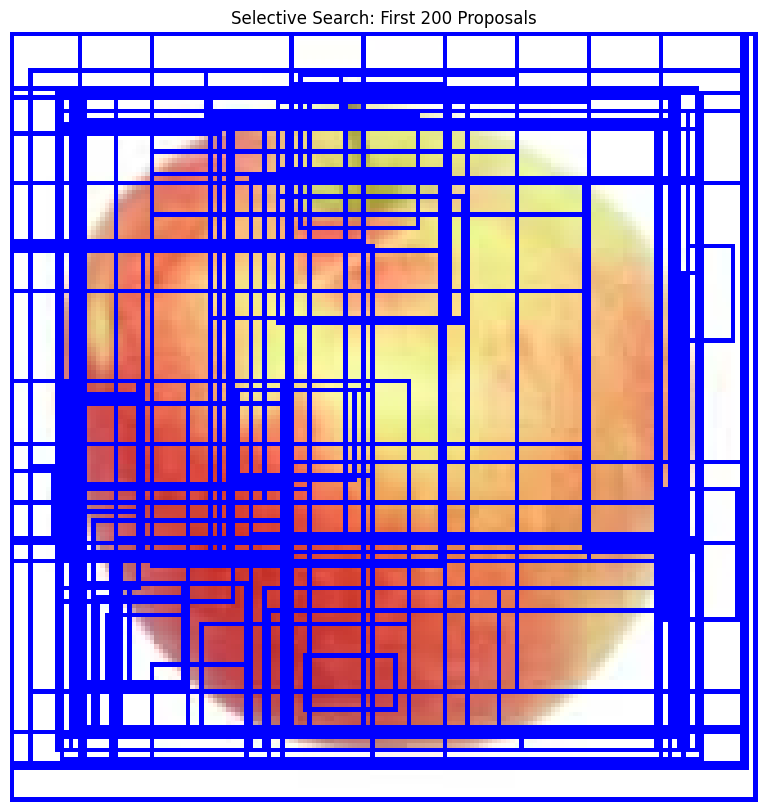

In [5]:
img_path_2, xml_path_2 = get_random_sample(TRAIN_DIR)
img_bgr_2 = read_bgr(img_path_2)

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_bgr_2)
ss.switchToSelectiveSearchFast()

rects = ss.process()[:200]

boxes_ss = []
for (x, y, ww, hh) in rects:
    boxes_ss.append([x, y, x + ww, y + hh])

img_ss = draw_boxes_cv2(img_bgr_2, boxes_ss, color=(255, 0, 0), thickness=1)

print("Image:", img_path_2)
print("Number of proposals:", len(boxes_ss))
show_bgr(img_ss, title="Selective Search: First 200 Proposals", figsize=(12, 10))

## Task 3 — R-CNN bottleneck: crop each proposal and pass through ResNet18

In [6]:
resnet_weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=resnet_weights).to(DEVICE).eval()
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE).eval()

img_tensor = get_image_tensor(img_path_2).to(DEVICE)
img_h, img_w = img_tensor.shape[1], img_tensor.shape[2]

top100_boxes = boxes_ss[:100]

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()

all_features = []
with torch.no_grad():
    for box in top100_boxes:
        x1, y1, x2, y2 = clamp_box_xyxy(box, img_w, img_h)
        if x2 <= x1 + 1 or y2 <= y1 + 1:
            continue

        crop = img_tensor[:, y1:y2, x1:x2].unsqueeze(0)
        crop = F.interpolate(crop, size=(224, 224), mode="bilinear", align_corners=False)
        crop = normalize_tensor(crop.squeeze(0)).unsqueeze(0)
        crop = crop.to(DEVICE)

        feat = feature_extractor(crop)
        all_features.append(feat.squeeze().cpu())

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

task3_time = end_time - start_time
print("Task 3 time for {} crops: {:.4f} seconds".format(len(all_features), task3_time))
print("First feature vector shape:", all_features[0].shape if all_features else None)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 143MB/s]


Task 3 time for 100 crops: 19.7521 seconds
First feature vector shape: torch.Size([512])


## Task 4 — Fast R-CNN idea: one CNN pass + RoI pooling

In [7]:
backbone = nn.Sequential(*list(resnet.children())[:-2]).to(DEVICE).eval()

img_tensor_full = get_image_tensor(img_path_2).to(DEVICE)
img_tensor_norm = normalize_tensor(img_tensor_full)
img_h, img_w = img_tensor_norm.shape[1], img_tensor_norm.shape[2]

roi_boxes = torch.tensor(
    [[float(b[0]), float(b[1]), float(b[2]), float(b[3])] for b in top100_boxes],
    dtype=torch.float32,
    device=DEVICE
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.no_grad():
    feature_map = backbone(img_tensor_norm.unsqueeze(0))
    feat_h, feat_w = feature_map.shape[-2], feature_map.shape[-1]
    spatial_scale = feat_w / img_w

    pooled = roi_pool(
        feature_map,
        [roi_boxes],
        output_size=(7, 7),
        spatial_scale=spatial_scale
    )

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

task4_time = end_time - start_time
print("Task 4 time (1 CNN pass + RoI pool): {:.4f} seconds".format(task4_time))
print("Feature map shape:", feature_map.shape)
print("RoI pooled output shape:", pooled.shape)
print("Spatial scale:", spatial_scale)
print("Speedup over Task 3:", task3_time / task4_time if task4_time > 0 else "inf")

Task 4 time (1 CNN pass + RoI pool): 0.1065 seconds
Feature map shape: torch.Size([1, 512, 6, 6])
RoI pooled output shape: torch.Size([100, 512, 7, 7])
Spatial scale: 0.03614457831325301
Speedup over Task 3: 185.5174083024832


### Conceptual Analysis — Task 4

Fast R-CNN removes the repeated CNN computation done in plain R-CNN.

In R-CNN, every proposal is cropped and sent through the CNN separately, so the same image regions are processed many times. Fast R-CNN runs the CNN once on the full image, then uses RoI pooling to extract fixed-size features for each proposal from the shared feature map.

So the redundant operations eliminated are:
- repeated convolution on overlapping crops,
- repeated feature extraction for each box,
- repeated forward passes through the same network.

## Task 5 — Faster R-CNN inference and filtering

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 160MB/s]


Image: /content/unzipped_archive/test_zip/test/banana_94.jpg
Raw predictions: 8
Filtered predictions: 0


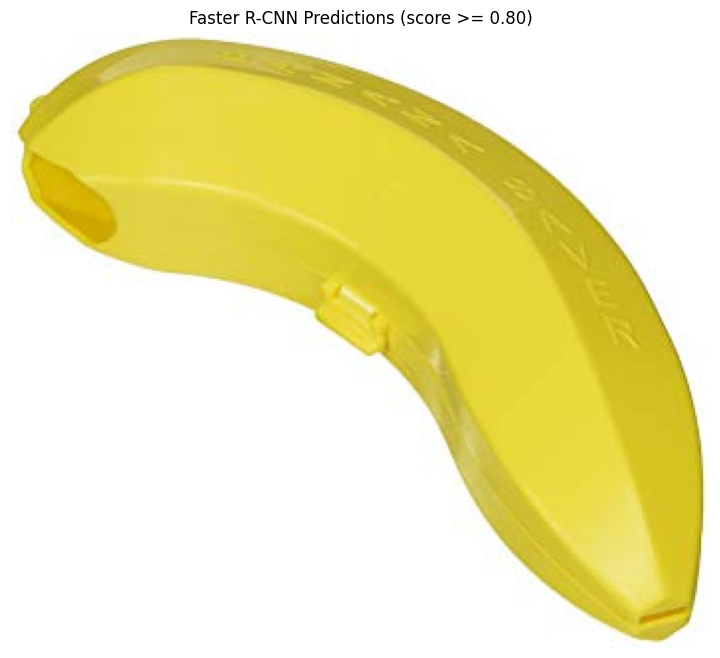

In [8]:
weights_frcnn = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
frcnn = fasterrcnn_resnet50_fpn(weights=weights_frcnn).to(DEVICE).eval()
coco_categories = weights_frcnn.meta["categories"]

img_path_5, xml_path_5 = get_random_sample(TEST_DIR)
img_bgr_5 = read_bgr(img_path_5)

img_tensor_5 = get_image_tensor(img_path_5).to(DEVICE)

with torch.no_grad():
    pred = frcnn([img_tensor_5])[0]

boxes = pred["boxes"].detach().cpu().numpy()
labels = pred["labels"].detach().cpu().numpy()
scores = pred["scores"].detach().cpu().numpy()

def filter_predictions(boxes, labels, scores, score_thresh=0.80):
    keep = scores >= score_thresh
    return boxes[keep], labels[keep], scores[keep]

f_boxes, f_labels, f_scores = filter_predictions(boxes, labels, scores, score_thresh=0.80)

label_names = []
for lab in f_labels:
    if int(lab) < len(coco_categories):
        label_names.append(coco_categories[int(lab)].lower())
    else:
        label_names.append(str(lab).lower())

img_frcnn = draw_boxes_cv2(img_bgr_5, f_boxes, labels=label_names, scores=f_scores, color=(0, 0, 255), thickness=2)

print("Image:", img_path_5)
print("Raw predictions:", len(boxes))
print("Filtered predictions:", len(f_boxes))
show_bgr(img_frcnn, title="Faster R-CNN Predictions (score >= 0.80)")

### Conceptual Analysis — Task 5

Faster R-CNN uses a Region Proposal Network (RPN) inside the model.

Instead of relying on an external algorithm like Selective Search, the RPN slides over the shared feature map and predicts objectness scores plus bounding-box adjustments for anchor boxes. Because proposal generation is learned and built into the network, the model no longer needs a separate hand-crafted proposal step.

## Task 6 — Custom Non-Maximum Suppression (NMS)

In [9]:
def nms_custom(boxes, scores, iou_thresh=0.5):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)

    order = scores.argsort()[::-1]
    keep = []

    while len(order) > 0:
        i = order[0]
        keep.append(i)

        remaining = order[1:]
        new_remaining = []
        for j in remaining:
            if iou_xyxy(boxes[i], boxes[j]) <= iou_thresh:
                new_remaining.append(j)

        order = np.array(new_remaining, dtype=np.int64)

    return keep

demo_boxes = [
    [10, 10, 100, 100],
    [15, 15, 105, 105],
    [120, 120, 200, 200],
    [130, 130, 210, 210]
]
demo_scores = [0.95, 0.90, 0.85, 0.60]

kept = nms_custom(demo_boxes, demo_scores, iou_thresh=0.5)
print("Kept indices:", kept)
print("Kept boxes:", [demo_boxes[i] for i in kept])
print("Kept scores:", [demo_scores[i] for i in kept])

Kept indices: [np.int64(0), np.int64(2)]
Kept boxes: [[10, 10, 100, 100], [120, 120, 200, 200]]
Kept scores: [0.95, 0.85]


### Conceptual Analysis — Task 6

An IoU threshold of 0.9 is very lenient, so boxes are only removed when they overlap almost perfectly. This keeps more nearby predictions, which may preserve tightly packed objects, but it also leaves more duplicates.

An IoU threshold of 0.1 is very strict, so even moderately overlapping boxes get removed. This suppresses duplicates aggressively, but for a cluster of close apples it can wrongly delete valid detections.

So:
- 0.9 keeps more boxes,
- 0.1 removes more boxes and may miss close objects.

## Task 7 — YOLO fine-tuning, evaluation, and visualization

path: /content/fruit_yolo_data

train: images/train
val: images/val
test: images/test

names:
  0: apple
  1: banana
  2: orange
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fruit_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

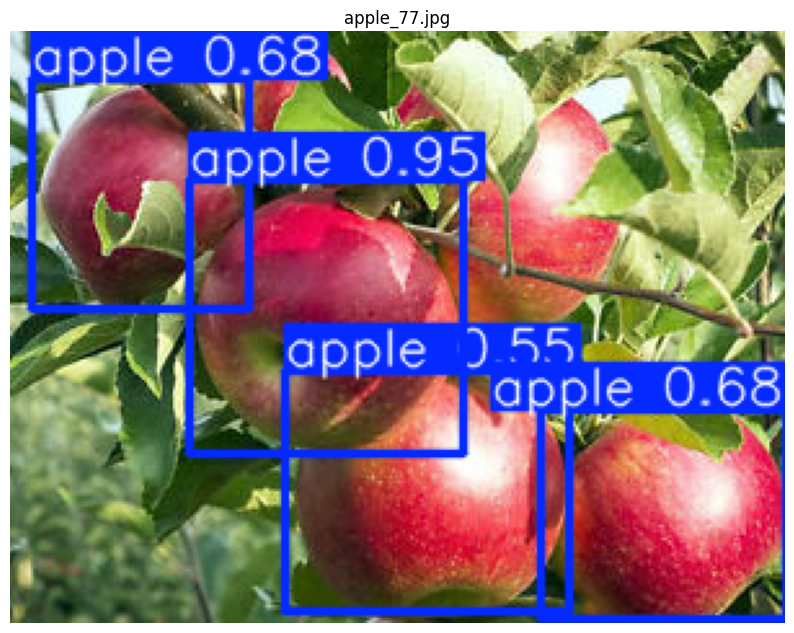

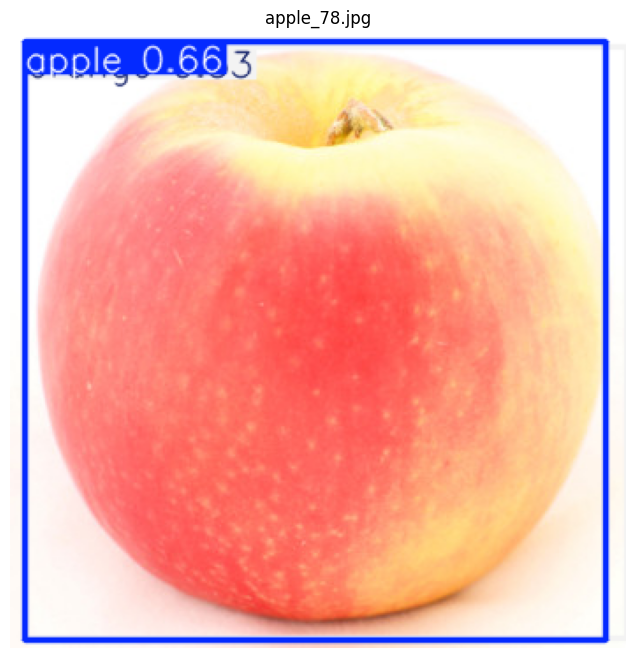

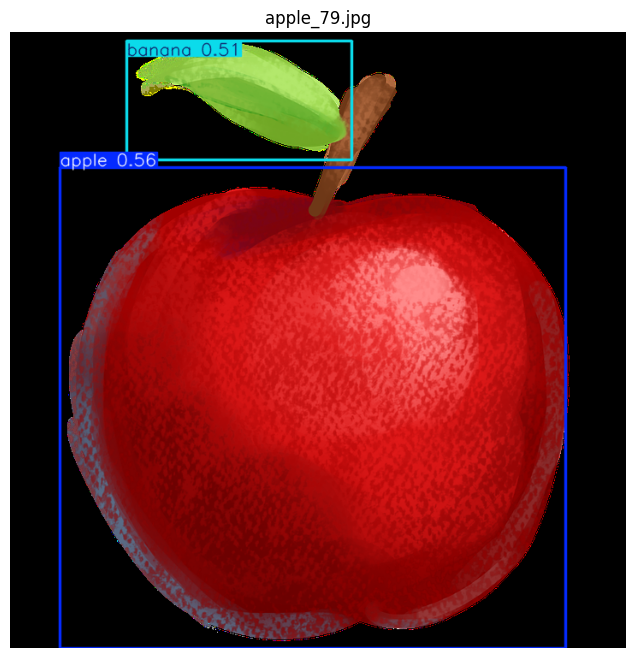

In [10]:
YOLO_ROOT = "/content/fruit_yolo_data"
YOLO_IMAGES = {
    "train": os.path.join(YOLO_ROOT, "images", "train"),
    "val": os.path.join(YOLO_ROOT, "images", "val"),
    "test": os.path.join(YOLO_ROOT, "images", "test"),
}
YOLO_LABELS = {
    "train": os.path.join(YOLO_ROOT, "labels", "train"),
    "val": os.path.join(YOLO_ROOT, "labels", "val"),
    "test": os.path.join(YOLO_ROOT, "labels", "test"),
}

for p in [YOLO_IMAGES["train"], YOLO_IMAGES["val"], YOLO_IMAGES["test"],
          YOLO_LABELS["train"], YOLO_LABELS["val"], YOLO_LABELS["test"]]:
    os.makedirs(p, exist_ok=True)

def voc_to_yolo_lines(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall("object"):
        cls_name = obj.find("name").text.strip().lower()
        if cls_name not in CLASS_MAP:
            continue
        cls_id = CLASS_MAP[cls_name]
        bnd = obj.find("bndbox")
        x1 = float(bnd.find("xmin").text)
        y1 = float(bnd.find("ymin").text)
        x2 = float(bnd.find("xmax").text)
        y2 = float(bnd.find("ymax").text)

        xc = (x1 + x2) / 2.0 / img_w
        yc = (y1 + y2) / 2.0 / img_h
        bw = (x2 - x1) / img_w
        bh = (y2 - y1) / img_h

        lines.append("{} {:.6f} {:.6f} {:.6f} {:.6f}".format(cls_id, xc, yc, bw, bh))
    return lines

def copy_and_convert(image_paths, split_name):
    for img_path in image_paths:
        xml_path = find_xml(img_path)
        if not os.path.exists(xml_path):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        out_img = os.path.join(YOLO_IMAGES[split_name], os.path.basename(img_path))
        out_lbl = os.path.join(YOLO_LABELS[split_name], Path(img_path).stem + ".txt")

        shutil.copy2(img_path, out_img)

        lines = voc_to_yolo_lines(xml_path, w, h)
        with open(out_lbl, "w") as f:
            f.write("\n".join(lines))

train_image_paths = list_images(TRAIN_DIR)
random.shuffle(train_image_paths)
train_paths, val_paths = train_test_split(train_image_paths, test_size=0.15, random_state=42)

for p in [YOLO_IMAGES["train"], YOLO_IMAGES["val"], YOLO_IMAGES["test"],
          YOLO_LABELS["train"], YOLO_LABELS["val"], YOLO_LABELS["test"]]:
    shutil.rmtree(p, ignore_errors=True)
    os.makedirs(p, exist_ok=True)

copy_and_convert(train_paths, "train")
copy_and_convert(val_paths, "val")
copy_and_convert(list_images(TEST_DIR), "test")

DATA_YAML = "/content/fruit_data.yaml"

yaml_text = """
path: /content/fruit_yolo_data

train: images/train
val: images/val
test: images/test

names:
  0: apple
  1: banana
  2: orange
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_text.strip())

print(open(DATA_YAML).read())

yolo_model = YOLO("yolov8n.pt")

train_results = yolo_model.train(
    data=DATA_YAML,
    epochs=10,
    imgsz=640,
    batch=16 if DEVICE.type == "cuda" else 2,
    device=0 if DEVICE.type == "cuda" else "cpu",
    project="/content/runs",
    name="fruit_yolo_finetune",
    exist_ok=True
)

best_weights = "/content/runs/fruit_yolo_finetune/weights/best.pt"
ft_model = YOLO(best_weights)

metrics = ft_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    device=0 if DEVICE.type == "cuda" else "cpu"
)

try:
    map50 = float(metrics.box.map50)
    map5095 = float(metrics.box.map)
except Exception:
    res = metrics.results_dict
    map50 = float(res.get("metrics/mAP50(B)", 0.0))
    map5095 = float(res.get("metrics/mAP50-95(B)", 0.0))

print("mAP@50:", map50)
print("mAP@50-95:", map5095)

test_images = sorted(list_images(YOLO_IMAGES["test"]))[:3]
print("Three test images:", test_images)

for p in test_images:
    result = ft_model.predict(source=p, conf=0.25, verbose=False)[0]
    plotted = result.plot()
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(p))
    plt.axis("off")
    plt.show()

## Task 7 — Comparison table: Faster R-CNN vs YOLO pre-trained vs YOLO fine-tuned

In [11]:
def load_gt_for_eval(image_path):
    xml_path = find_xml(image_path)
    gt_boxes, gt_labels = parse_voc_xml(xml_path)
    gt_labels = [x.lower() for x in gt_labels]
    return gt_boxes, gt_labels

def predict_frcnn(model, image_path):
    img_tensor = get_image_tensor(image_path).to(DEVICE)
    with torch.no_grad():
        pred = model([img_tensor])[0]
    boxes = pred["boxes"].detach().cpu().numpy().tolist()
    scores = pred["scores"].detach().cpu().numpy().tolist()
    labels = pred["labels"].detach().cpu().numpy().tolist()

    names = []
    cats = weights_frcnn.meta["categories"]
    for lab in labels:
        if int(lab) < len(cats):
            names.append(cats[int(lab)].lower())
        else:
            names.append(str(lab).lower())
    return boxes, names, scores

def predict_yolo(model, image_path):
    result = model.predict(source=image_path, conf=0.001, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        return [], [], []
    boxes = result.boxes.xyxy.cpu().numpy().tolist()
    scores = result.boxes.conf.cpu().numpy().tolist()
    cls_ids = result.boxes.cls.cpu().numpy().astype(int).tolist()
    names_map = result.names
    labels = [names_map[c].lower() if isinstance(names_map, dict) else names_map[c].lower() for c in cls_ids]
    return boxes, labels, scores

def evaluate_detector(image_paths, predictor_fn, model_name, conf_thresh=0.25, iou_thresh=0.5):
    times = []
    tp_total = fp_total = fn_total = 0

    for img_path in image_paths:
        gt_boxes, gt_labels = load_gt_for_eval(img_path)

        start = time.perf_counter()
        pred_boxes, pred_labels, pred_scores = predictor_fn(img_path)
        end = time.perf_counter()
        times.append((end - start) * 1000)

        keep = [i for i, s in enumerate(pred_scores) if s >= conf_thresh]
        pred_boxes = [pred_boxes[i] for i in keep]
        pred_labels = [pred_labels[i] for i in keep]
        pred_scores = [pred_scores[i] for i in keep]

        used_gt = set()
        tp = fp = 0

        order = np.argsort(-np.array(pred_scores)) if len(pred_scores) > 0 else []
        for idx in order:
            pbox = pred_boxes[idx]
            plabel = str(pred_labels[idx]).lower()

            best_iou = 0
            best_gt = -1
            for gidx, (gbox, glabel) in enumerate(zip(gt_boxes, gt_labels)):
                if gidx in used_gt:
                    continue
                if plabel != str(glabel).lower():
                    continue
                iou_val = iou_xyxy(pbox, gbox)
                if iou_val > best_iou:
                    best_iou = iou_val
                    best_gt = gidx

            if best_gt >= 0 and best_iou >= iou_thresh:
                tp += 1
                used_gt.add(best_gt)
            else:
                fp += 1

        fn = len(gt_boxes) - len(used_gt)
        tp_total += tp
        fp_total += fp
        fn_total += fn

    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall = tp_total / (tp_total + fn_total + 1e-9)
    mean_time = float(np.mean(times)) if times else 0.0

    return {
        "Model": model_name,
        "Inference Time (ms/image)": mean_time,
        "Precision": precision,
        "Recall": recall
    }

test_img_paths = sorted(list_images(TEST_DIR))[:10]

faster_rcnn_model = frcnn
yolo_pretrained = YOLO("yolov8n.pt")
yolo_finetuned = YOLO(best_weights)

results = []
results.append(evaluate_detector(
    test_img_paths,
    predictor_fn=lambda p: predict_frcnn(faster_rcnn_model, p),
    model_name="Faster R-CNN (pre-trained)",
    conf_thresh=0.80,
    iou_thresh=0.5
))
results.append(evaluate_detector(
    test_img_paths,
    predictor_fn=lambda p: predict_yolo(yolo_pretrained, p),
    model_name="YOLO (pre-trained)",
    conf_thresh=0.25,
    iou_thresh=0.5
))
results.append(evaluate_detector(
    test_img_paths,
    predictor_fn=lambda p: predict_yolo(yolo_finetuned, p),
    model_name="YOLO (fine-tuned)",
    conf_thresh=0.25,
    iou_thresh=0.5
))

df = pd.DataFrame(results)
df

,Model,Inference Time (ms/image),Precision,Recall
0,Faster R-CNN (pre-trained),6616.530402,0.538462,0.823529
1,YOLO (pre-trained),193.223039,0.538462,0.823529
2,YOLO (fine-tuned),180.823916,0.700000,0.823529


## Final report summary

Task 3 is slow because every proposal is cropped and processed separately by the CNN.

Task 4 is much faster because the CNN runs only once on the whole image, and RoI pooling reuses the shared feature map.

Faster R-CNN improves proposal generation with an internal RPN, so it does not need Selective Search.

NMS removes duplicate predictions by keeping the best scoring box and suppressing highly overlapping boxes.

YOLO fine-tuning adapts the detector to the fruit dataset and should give the best results on this task.